In [ ]:
import numpy as np
import scipy.signal as signal
from scipy.optimize import minimize
import matplotlib.pyplot as plt

def generate_psd(f, cutoff, n, turb_power, noise_power):
    """
    Generates the Turbulence and Noise PSDs normalized to the requested total powers.
    """
    f_safe = np.maximum(f, f[0])
    if n == 1:
        psd_turb = np.where(f_safe <= cutoff, 
                            (f_safe / cutoff)**(-2/3), 
                            (f_safe / cutoff)**(-17/3))
    else:
        psd_turb = np.where(f_safe <= cutoff, 
                            1.0, 
                            (f_safe / cutoff)**(-17/3))
        
    # Precompute integration weights for normalization
    df = np.gradient(f)
    
    turb_integral = np.sum(psd_turb * df)
    psd_turb *= (turb_power / turb_integral)
    
    psd_noise = np.ones_like(f)
    noise_integral = np.sum(psd_noise * df)
    psd_noise *= (noise_power / noise_integral)
    
    return psd_turb, psd_noise

def evaluate_filter(params, order, f, fs, psd_turb, psd_noise, delay_phasor, df, min_gain_margin_db=3.0):
    """
    Evaluates the residual variance for a given set of filter coefficients.
    Optimized for tight inner-loop execution.
    """
    b = params[:order+1]
    a = np.concatenate(([1.0], params[order+1:]))
    
    # 1. Smooth Stability Penalty
    roots = np.roots(a)
    max_pole = np.max(np.abs(roots)) if len(roots) > 0 else 0
    if max_pole >= 0.99:
        # Provide a continuous slope back toward stability
        return 1e6 * (1.0 + (max_pole - 0.99)**2) 
    
    # 2. Compute Open Loop Transfer Function
    # worN=f passes the specific frequencies, avoiding default linspace
    _, h_filter = signal.freqz(b, a, worN=f, fs=fs)
    h_ol = h_filter * delay_phasor
    
    # 3. Smooth Gain Margin Penalty
    phase = np.unwrap(np.angle(h_ol))
    crossings = np.where(phase <= -np.pi)[0]
    
    if len(crossings) > 0:
        idx = crossings[0]
        gm_db = -20 * np.log10(np.abs(h_ol[idx]) + 1e-15)
        if gm_db < min_gain_margin_db:
            # Smooth penalty gradient
            return 1e5 + (min_gain_margin_db - gm_db)**2 * 1e4
    
    # 4. Compute Transfer Functions
    # Using element-wise arithmetic minimizes array allocations
    denom_mag2 = np.abs(1.0 + h_ol)**2
    S_mag2 = 1.0 / denom_mag2
    T_mag2 = np.abs(h_ol)**2 / denom_mag2
    
    # 5. Fast Vectorized Integration
    residual_psd = S_mag2 * psd_turb + T_mag2 * psd_noise
    total_residual = np.sum(residual_psd * df)
    
    return total_residual

# def evaluate_filter_refined(params, order, f, fs, psd_turb, psd_noise, delay_phasor, df, min_gain_margin_db=3.0):
#     b = params[:order+1]
#     a = np.concatenate(([1.0], params[order+1:]))

#     # Calculate frequency response
#     _, h_filter = signal.freqz(b, a, worN=f, fs=fs)
#     h_ol = h_filter * delay_phasor
    
#     # Vectorized denominator calculation
#     denom = 1.0 + h_ol
#     denom_mag2 = np.real(denom * np.conj(denom))
    
#     # Avoid division by zero/singularities
#     denom_mag2 = np.maximum(denom_mag2, 1e-12)
    
#     # S and T magnitudes
#     S_mag2 = 1.0 / denom_mag2
#     T_mag2 = np.real(h_ol * np.conj(h_ol)) / denom_mag2
    
#     # Calculate Gain Margin (GM)
#     # Find frequency where phase is -180 degrees
#     phase = np.angle(h_ol)
#     # Find the index closest to -pi
#     idx_pi = np.argmin(np.abs(phase + np.pi))
#     gm_linear = 1.0 / (np.abs(h_ol[idx_pi]) + 1e-15)
#     gm_db = 20 * np.log10(gm_linear)
    
#     # Residual Variance
#     residual_psd = S_mag2 * psd_turb + T_mag2 * psd_noise
#     total_residual = np.sum(residual_psd * df)
    
#     # Stability penalty (Poles check)
#     roots = np.roots(a)
#     max_pole = np.abs(roots).max() if len(roots) > 0 else 0
    
#     penalty = 0
#     if max_pole >= 0.98:
#         penalty += (max_pole - 0.98) * 1e7
#     if gm_db < min_gain_margin_db:
#         penalty += (min_gain_margin_db - gm_db)**2 * 1e5
        
#     return total_residual + penalty

def optimize_filter_ladder(target_order, delay_steps, fs, cutoff, n, turb_power, noise_power, min_gain_margin_db=3.0, verbose=True):
    """
    Optimizes an IIR filter up to target_order using ladder initialization.
    """
    # Define frequency vector
    f = np.logspace(np.log10(0.1), np.log10(fs/2), 2000)
    
    # Precompute Loop Constants to save inner-loop CPU time
    psd_turb, psd_noise = generate_psd(f, cutoff, n, turb_power, noise_power)
    delay_phasor = np.exp(-1j * 2 * np.pi * f / fs * delay_steps)
    df = np.gradient(f) 
    
    # Base Case Initialization for Order 1 [b0, b1, a1]
    current_params = np.array([0.1, 0.0, -0.9]) 
    
    if verbose:
        print(f"=== Starting Ladder Optimization up to Order {target_order} ===")
        print(f"Turbulence Power: {turb_power:.2e} | Noise Power: {noise_power:.2e}")

    a_opts = []
    b_opts = []
    residuals = np.zeros(target_order)
    
    for current_order in range(1, target_order + 1):
        if verbose:
            print(f"\n--- Optimizing Order {current_order} ---")
            
        res = minimize(
            evaluate_filter, 
            current_params, 
            args=(current_order, f, fs, psd_turb, psd_noise, delay_phasor, df, min_gain_margin_db),
            method='Nelder-Mead', 
            options={'maxiter': 10000 * current_order, 'xatol': 1e-6, 'fatol': 1e-6}
        )
        
        b_opt = res.x[:current_order+1]
        a_opt = np.concatenate(([1.0], res.x[current_order+1:]))

        b_opts.append(b_opt)
        a_opts.append(a_opt)
        residuals[current_order-1] = res.fun
        
        if verbose:
            print(f"Convergence: {'Success' if res.success else 'Failed'} ({res.message})")
            print(f"Residual Variance: {res.fun:.4e}")
            print(f"b coeffs: {b_opt}")
            print(f"a coeffs: {a_opt}")
        
        # Advance ladder: pad with tiny noise instead of strict 0.0 to break saddle points
        if current_order < target_order:
            b_next = np.append(b_opt, 1e-5)
            a_next = np.append(res.x[current_order+1:], 1e-5) 
            current_params = np.concatenate((b_next, a_next))
            
    return b_opts, a_opts, residuals



def plot_filter_performance(fs, cutoff, n, turb_power, noise_power, filter_results, delay_steps):
    """
    Plots the PSD amplitudes and the transfer functions for comparison.
    
    filter_results: List of tuples [(b, a, "Label"), ...]
    """
    f = np.logspace(np.log10(0.1), np.log10(fs/2), 2000)
    psd_turb, psd_noise = generate_psd(f, cutoff, n, turb_power, noise_power)
    delay_phasor = np.exp(-1j * 2 * np.pi * f / fs * delay_steps)
    plt.figure(figsize=(12, 7))
    for b, a, label in filter_results:
        _, h_filter = signal.freqz(b, a, worN=f, fs=fs)
        h_ol = h_filter * delay_phasor
        S = 1.0 / (1.0 + h_ol)
        plt.loglog(f, np.abs(S), label=f'RTF - {label}')
    plt.loglog(f, np.sqrt(psd_turb), label=r'Turbulence Amplitude ($\sqrt{\Phi_{turb}}$)', color='blue', lw=2)
    plt.loglog(f, np.sqrt(psd_noise), label=r'Noise Amplitude ($\sqrt{\Phi_{noise}}$)', color='gray', linestyle='--')
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.grid(True, which="both", ls="-", alpha=0.4)
    plt.legend(ncol=2, fontsize='small')
    plt.ylim([0.1*np.sqrt(psd_noise[0]), np.sqrt(psd_turb[0])*2])
    plt.tight_layout()
    plt.show()


=== Starting Ladder Optimization up to Order 4 ===
Turbulence Power: 1.00e+03 | Noise Power: 1.00e+00

--- Optimizing Order 1 ---
Convergence: Success (Optimization terminated successfully.)
Residual Variance: 1.3714e+00
b coeffs: [0.23617728 0.12166682]
a coeffs: [ 1.   -0.99]

--- Optimizing Order 2 ---
Convergence: Success (Optimization terminated successfully.)
Residual Variance: 1.3189e+00
b coeffs: [ 3.79371479e-01 -6.52378378e-03  1.48418145e-05]
a coeffs: [ 1.00000000e+00 -9.90007241e-01  7.16858650e-06]

--- Optimizing Order 3 ---
Convergence: Success (Optimization terminated successfully.)
Residual Variance: 1.2466e+00
b coeffs: [ 0.32371347  0.18987028 -0.3573714   0.18652742]
a coeffs: [ 1.         -1.09403785  0.06725505  0.035385  ]

--- Optimizing Order 4 ---
Convergence: Success (Optimization terminated successfully.)
Residual Variance: 2.2670e-01
b coeffs: [ 0.19605825 -0.17209615 -0.1139804   0.17090653 -0.06084356]
a coeffs: [ 1.         -1.56702141  0.18493267  0.36

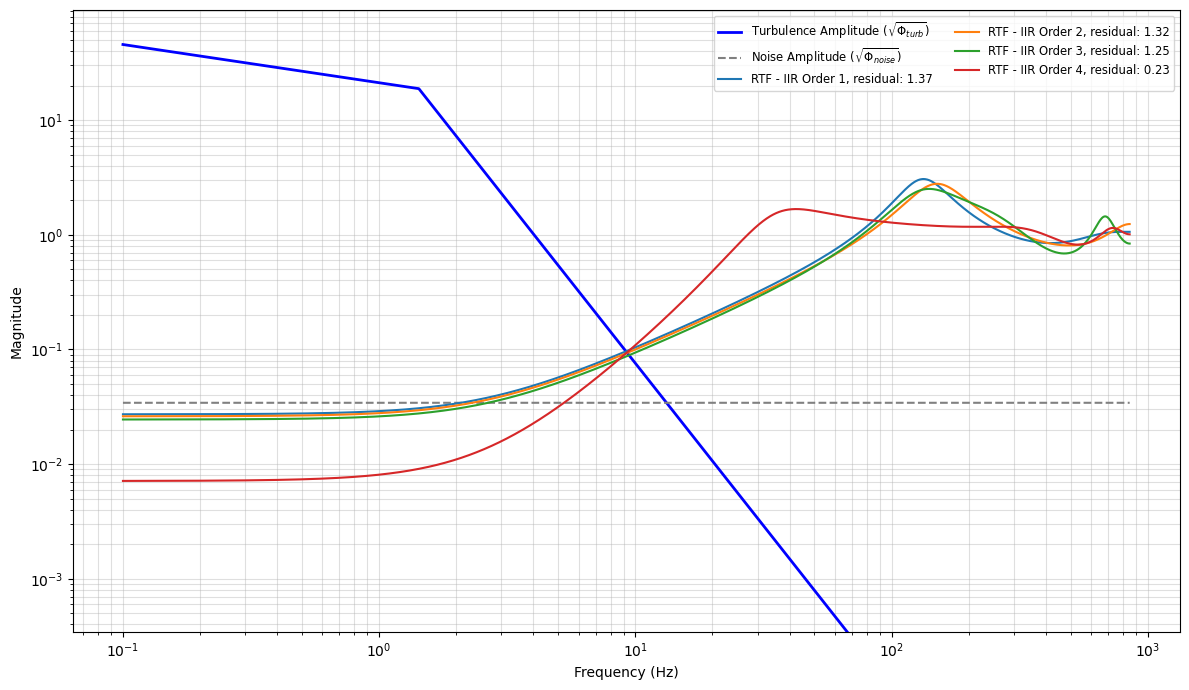

In [ ]:
V = 20
D = 8.4


FS = 1700.0             
DELAY_STEPS = 3         
N_RADIAL = 1            
CUTOFF_FREQ = 0.3 * (N_RADIAL + 1) * V/D      
TURB_POWER = 1000.0      
NOISE_POWER = 1       
TARGET_ORDER = 4

b_list, a_list, residuals = optimize_filter_ladder(
    target_order=TARGET_ORDER,
    delay_steps=DELAY_STEPS,
    fs=FS,
    cutoff=CUTOFF_FREQ,
    n=N_RADIAL,
    turb_power=TURB_POWER,
    noise_power=NOISE_POWER,
    verbose=True
)

results_list = []
for j in range(len(residuals)):
    results_list.append((b_list[j], a_list[j], f"IIR Order {j+1}, residual: {residuals[j]:1.2f}"))

plot_filter_performance(fs=FS, cutoff=CUTOFF_FREQ, n=N_RADIAL, turb_power=TURB_POWER, noise_power=NOISE_POWER, delay_steps=DELAY_STEPS, filter_results=results_list)

In [ ]:
# import numpy as np
# import scipy.signal as signal
# from scipy.optimize import minimize
# import matplotlib.pyplot as plt

# def get_psds(f, fc, fs, snr_linear):
#     """
#     Generates the Turbulence and Noise PSDs.
#     Turbulence is flat up to fc, then falls as f^(-17/3).
#     """
#     # 1. Turbulence PSD
#     psd_turb = np.ones_like(f)
#     mask = f > fc
#     psd_turb[mask] = (f[mask] / fc)**(-17/3)
    
#     # Normalize turbulence variance to 1.0 for reference
#     df = f[1] - f[0]
#     var_turb = np.sum(psd_turb) * df
#     psd_turb /= var_turb
    
#     # 2. Measurement Noise PSD (White noise assumption)
#     # SNR = Var(Turbulence) / Var(Noise)
#     var_noise = 1.0 / snr_linear
#     psd_noise = np.ones_like(f) * (var_noise / (fs / 2))
    
#     return psd_turb, psd_noise

# def evaluate_controller(params, num_zeros, num_poles, f, fs, N_delay, psd_turb, psd_noise, return_details=False):
#     """
#     Evaluates the residual variance for a given digital controller.
#     """
#     # Extract coefficients (scipy uses 'b' for numerator/zeros, 'a' for denominator/poles)
#     b = params[:num_zeros+1]
#     a = np.concatenate(([1.0], params[num_poles+1:]))
    
#     # 1. Controller Frequency Response
#     w = 2 * np.pi * f / fs
#     with np.errstate(divide='ignore', invalid='ignore'):
#         _, C = signal.freqz(b, a, worN=w)
        
#     # 2. Plant Frequency Response: Pure Fractional Delay
#     P = np.exp(-1j * 2 * np.pi * (f / fs) * N_delay)
    
#     # 3. Open Loop
#     H_open = P * C
    
#     # 4. Error Rejection (RTF) and Noise Transfer Functions (NTF)
#     RTF = 1.0 / (1.0 + H_open)
#     NTF = H_open / (1.0 + H_open)
        
#     # 5. Residual PSD and Variance
#     psd_res = (np.abs(RTF)**2) * (psd_turb+psd_noise) #+ (np.abs(NTF)**2) * psd_noise
#     df = f[1] - f[0]
#     variance = np.sum(psd_res) * df
    
#     # 6. Stability Constraints (Modulus Margin)
#     # The Nyquist contour must not get dangerously close to the -1 point.
#     modulus_margin = np.min(np.abs(1.0 + H_open[1:]))
#     penalty = 0.0
    
#     # Enforce robustness margin (e.g., minimum distance of 0.3 to critical point)
#     if modulus_margin < 0.1:
#         penalty += 1e6 * (0.1 - modulus_margin)
        
#     # Open-loop controller stability check
#     roots_a = np.roots(a)
#     if np.any(np.abs(roots_a) > 1.001): # allow integrator at 1.0
#         penalty += 1e7
        
#     if return_details:
#         return variance, psd_res, np.abs(RTF)**2, np.abs(NTF)**2
#     return variance + penalty

# def optimize_controller(order_zeros, order_poles, f, fs, N_delay, psd_turb, psd_noise):
#     """
#     Finds optimal filter coefficients using Nelder-Mead to handle the stability penalties.
#     """
#     # Initial guess: small gain proportional-integral-like behavior
#     b_guess = np.zeros(order_zeros+1)
#     b_guess[0] = 0.7
#     a_guess = np.zeros(order_poles)
#     a_guess[0] = -0.99 # close to integrator
        
#     x0 = np.concatenate((b_guess, a_guess))
    
#     res = minimize(
#         evaluate_controller, 
#         x0, 
#         args=(order_zeros, order_poles, f, fs, N_delay, psd_turb, psd_noise),
#         method='Nelder-Mead',
#         options={'maxiter': 10000, 'xatol': 1e-8, 'fatol': 1e-8}
#     )
    
#     b_opt = res.x[:order_zeros+1]
#     a_opt = np.concatenate(([1.0], res.x[order_poles+1:]))
#     return b_opt, a_opt, res.fun

In [ ]:
# # System Parameters
# D = 8.4
# V = 10
# n = 2

# fs = 1000.0 # Sampling frequency (Hz)
# N_delay = 2.0 # Pure fractional delay in steps
# fc = 0.3*V/D*(n+1) # Turbulence cutoff frequency (Hz)
# snr_db = 40.0 # Signal to noise ratio (dB)

# # Frequency grid (exclude 0 initially to avoid integrator div-by-zero, handle DC separately)
# f = np.linspace(0.1, fs/2, 2000) #np.logspace(-1, np.log10(fs/2), 2000)
# snr_linear = 10**(snr_db / 20)

# psd_turb, psd_noise = get_psds(f, fc, fs, snr_linear)

# print(f"Plant Delay: {N_delay} steps")
# print(f"Optimizing for SNR = {snr_db} dB...\n")

# # Define candidates: (num_zeros, num_poles, label)
# # order is number of poles and zeros
# candidates = [
#     # (0, 1, "Integrator (standard)"),
#     (1, 1, "Integrator (leaky)"),
#     # (1, 2, "Double integrator"),
#     (2, 2, "2P2Z"),
#     # (2, 3, "2P3Z"),
#     (3, 3, "3P3Z"),
# ]

# results = {}

# for zeros, poles, label in candidates:
#     b_opt, a_opt, final_var = optimize_controller(zeros, poles, f, fs, N_delay, psd_turb, psd_noise)
#     var_actual, psd_res, rtf_sq, ntf_sq = evaluate_controller(
#         np.concatenate((b_opt, a_opt[1:])), 
#         zeros, poles, f, fs, N_delay, psd_turb, psd_noise, return_details=True
#     )
#     results[label] = {
#         'variance': var_actual,
#         'psd': psd_res,
#         'rtf': rtf_sq,
#         'ntf': ntf_sq,
#         'b': b_opt,
#         'a': a_opt
#     }
#     print(f"{label}:")
#     print(f" Numerator (b): {np.round(b_opt, 4)}")
#     print(f" Denominator (a): {np.round(a_opt, 4)}")
#     print(f" Residual Variance: {var_actual:.4f}\n")

# # Plotting
# plt.figure(figsize=(10, 6))
# plt.loglog(f, psd_turb, 'k--', label='Input Turbulence PSD')
# plt.loglog(f, psd_noise, 'k:', label='Measurement Noise PSD')

# for label, data in results.items():
#     plt.loglog(f, data['psd'], label=f'Residual: {label}')
    
# plt.title('Residual Turbulence PSD Comparison')
# plt.xlabel('Frequency (Hz)')
# plt.ylabel('Power Spectral Density')
# plt.legend()
# plt.ylim([1e-9,1])
# plt.grid(True, which='both', ls='-', alpha=0.5)

# # Plotting
# plt.figure(figsize=(10, 6))
# for label, data in results.items():
#     plt.loglog(f,np.sqrt(data['rtf']), label=f'RTF: {label}')
# plt.xlabel('Frequency (Hz)')
# plt.legend()
# plt.ylim([1e-4,10])
# plt.grid(True, which='both', ls='-', alpha=0.5)

# plt.figure(figsize=(10, 6))
# for label, data in results.items():
#     plt.loglog(f,np.sqrt(data['ntf']), label=f'NTF: {label}')
# plt.xlabel('Frequency (Hz)')
# plt.legend()
# plt.grid(True, which='both', ls='-', alpha=0.5)